In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV

In [2]:
df=pd.read_csv("CarPrice_Assignment.csv")
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [4]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [5]:
df.shape

(205, 26)

In [6]:
df[df.duplicated()]

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price


In [7]:
df.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

In [8]:
df.drop(columns="car_ID",axis=1,inplace=True)

In [9]:
Out_col1=df.select_dtypes(include=np.number)
Out_col1

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,109.1,188.8,68.9,55.5,2952,141,3.78,3.15,9.5,114,5400,23,28,16845.0
201,-1,109.1,188.8,68.8,55.5,3049,141,3.78,3.15,8.7,160,5300,19,25,19045.0
202,-1,109.1,188.8,68.9,55.5,3012,173,3.58,2.87,8.8,134,5500,18,23,21485.0
203,-1,109.1,188.8,68.9,55.5,3217,145,3.01,3.40,23.0,106,4800,26,27,22470.0


In [10]:
Out_col=["symboling","wheelbase",	"carlength",	"carwidth",	"carheight",	"curbweight",	"enginesize",	"boreratio",	"stroke",	"compressionratio",	"horsepower",	"peakrpm",	"citympg",	"highwaympg"]

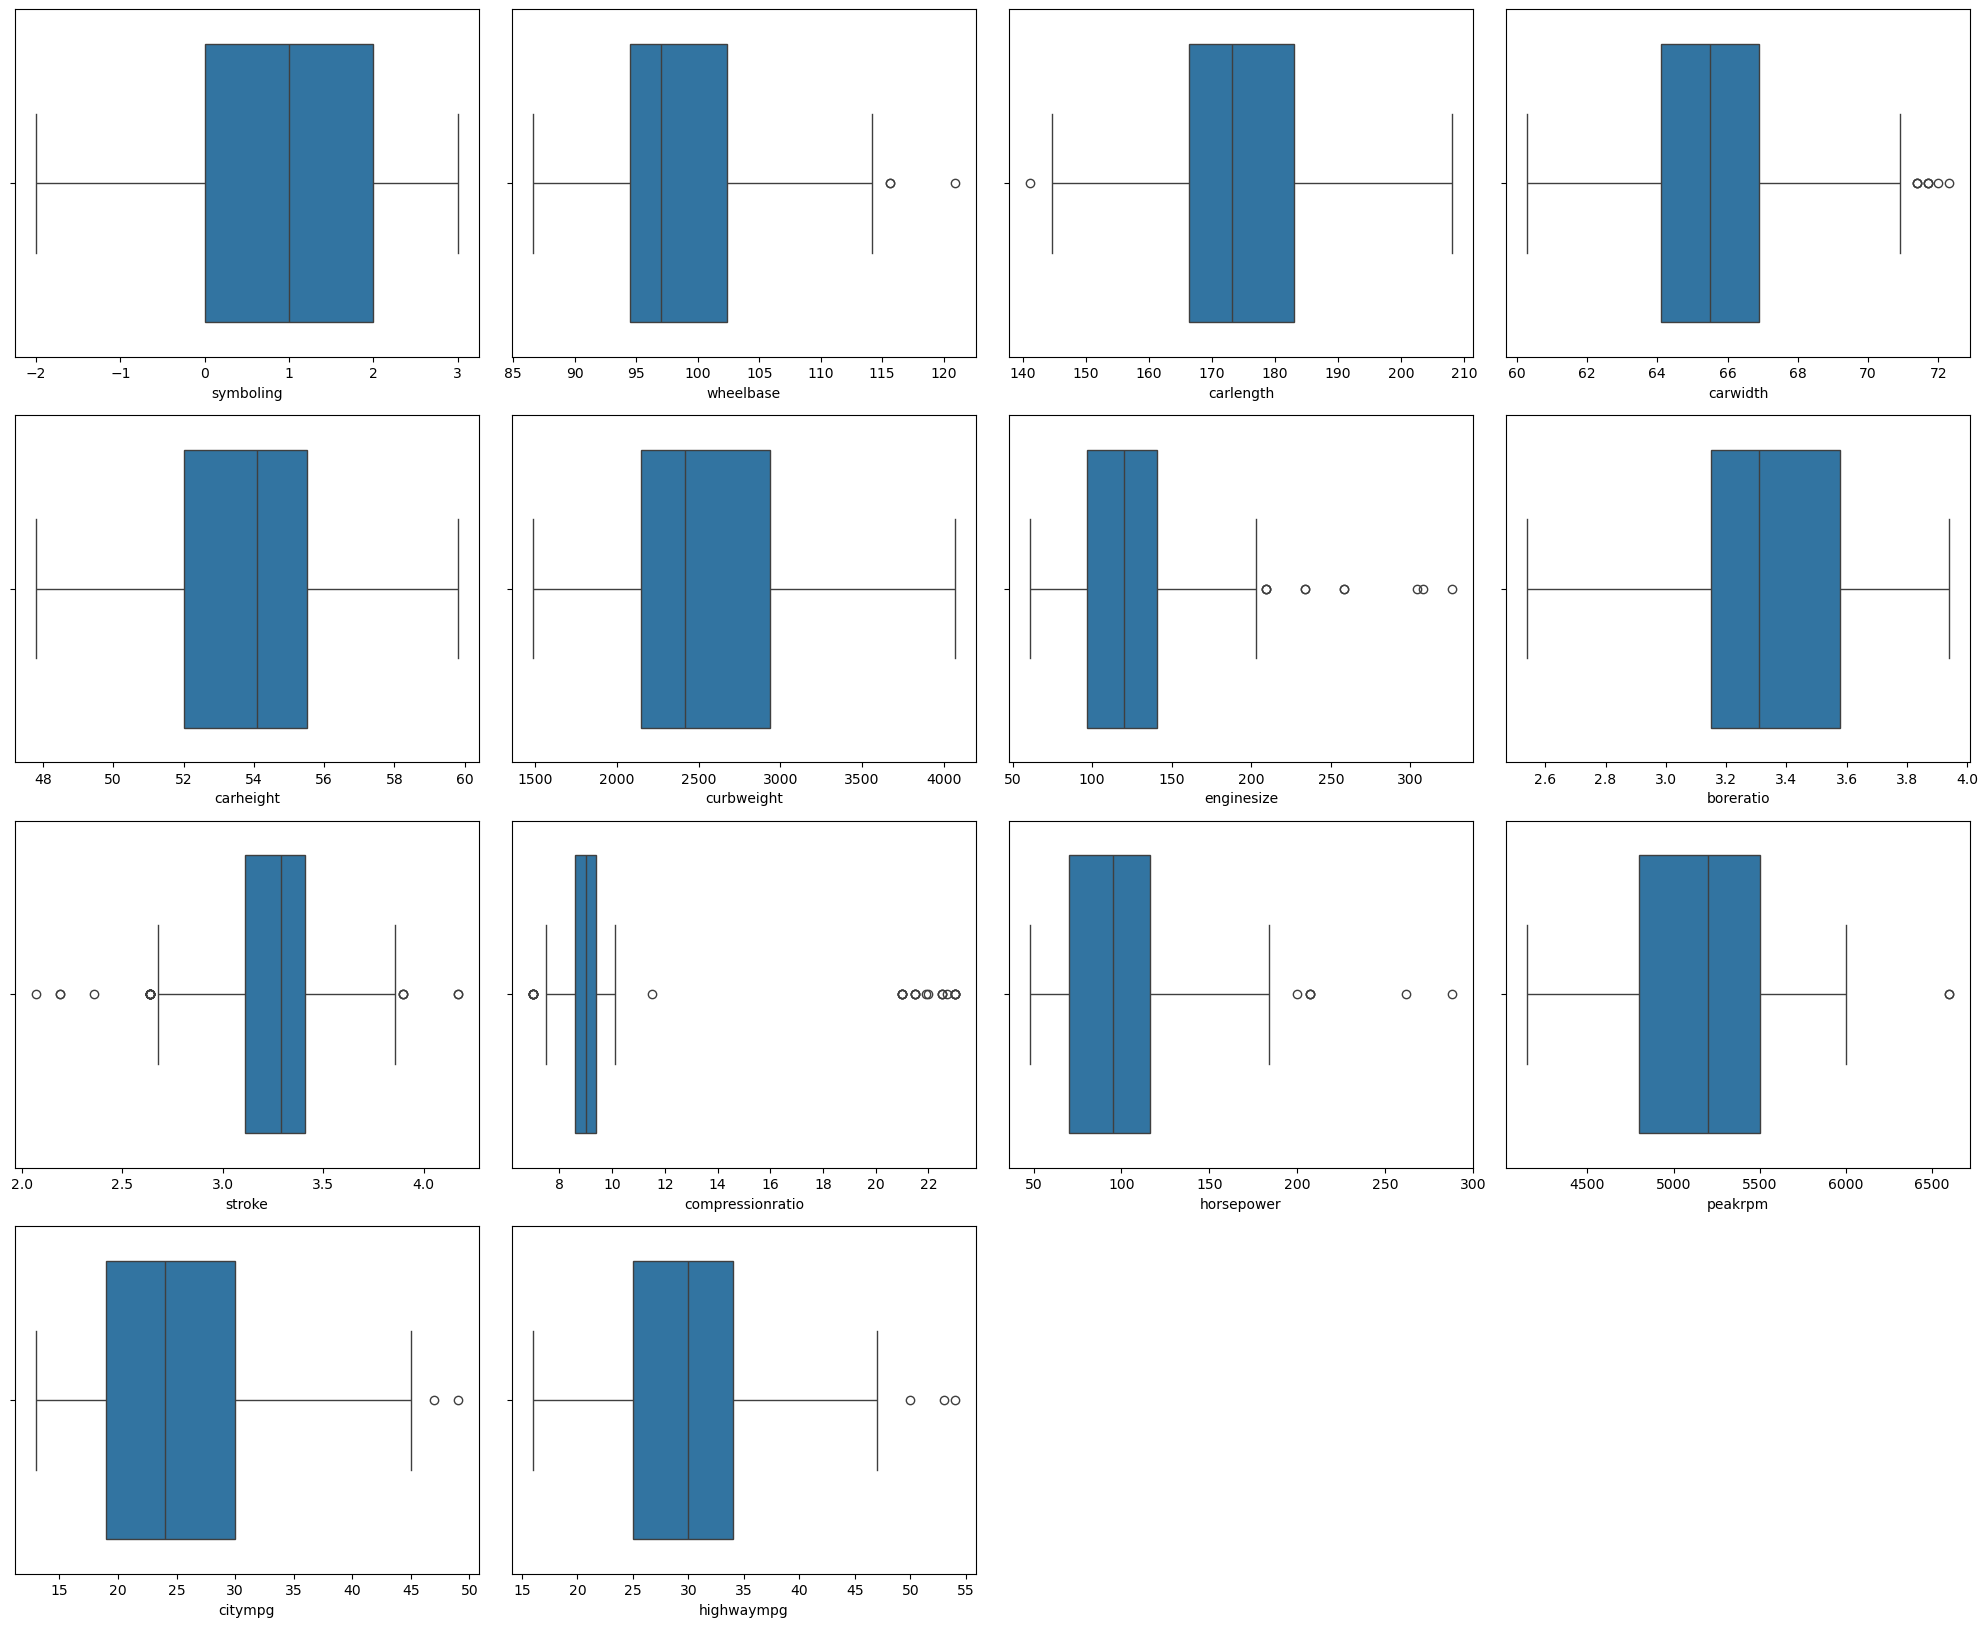

In [11]:
plt.figure(figsize=(20,20))
plotnumber=1
for col in Out_col:
    if (plotnumber<20):
        plt.subplot(5,4,plotnumber)
        sns.boxplot(data=df,x=col)
    plotnumber+=1
plt.tight_layout()


In [12]:
def rem_Out(data,col):
    q1,q2,q3=np.percentile(data[col],(25,50,75))
    IQR=q3-q1
    LF=q1-(1.5*IQR)
    UF=q3+(1.5*IQR)
    data[col]=np.where(data[col]<q1,LF,data[col])
    data[col]=np.where(data[col]>q3,UF,data[col])

In [13]:
for col in Out_col:
    rem_Out(df,col)

In [14]:
df.head()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,5.0,alfa-romero giulia,gas,std,two,convertible,rwd,front,82.65,168.8,...,130.0,mpfi,3.470,2.66,9.0,111.0,5000.0,21.0,27.0,13495.0
1,5.0,alfa-romero stelvio,gas,std,two,convertible,rwd,front,82.65,168.8,...,130.0,mpfi,3.470,2.66,9.0,111.0,5000.0,21.0,27.0,16500.0
2,1.0,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.50,171.2,...,207.0,mpfi,2.505,3.86,9.0,185.0,5000.0,19.0,26.0,16500.0
3,2.0,audi 100 ls,gas,std,four,sedan,fwd,front,99.80,176.6,...,109.0,mpfi,3.190,3.40,10.6,102.0,5500.0,24.0,30.0,13950.0
4,2.0,audi 100ls,gas,std,four,sedan,4wd,front,99.40,176.6,...,136.0,mpfi,3.190,3.40,7.4,115.0,5500.0,2.5,11.5,17450.0


<Axes: >

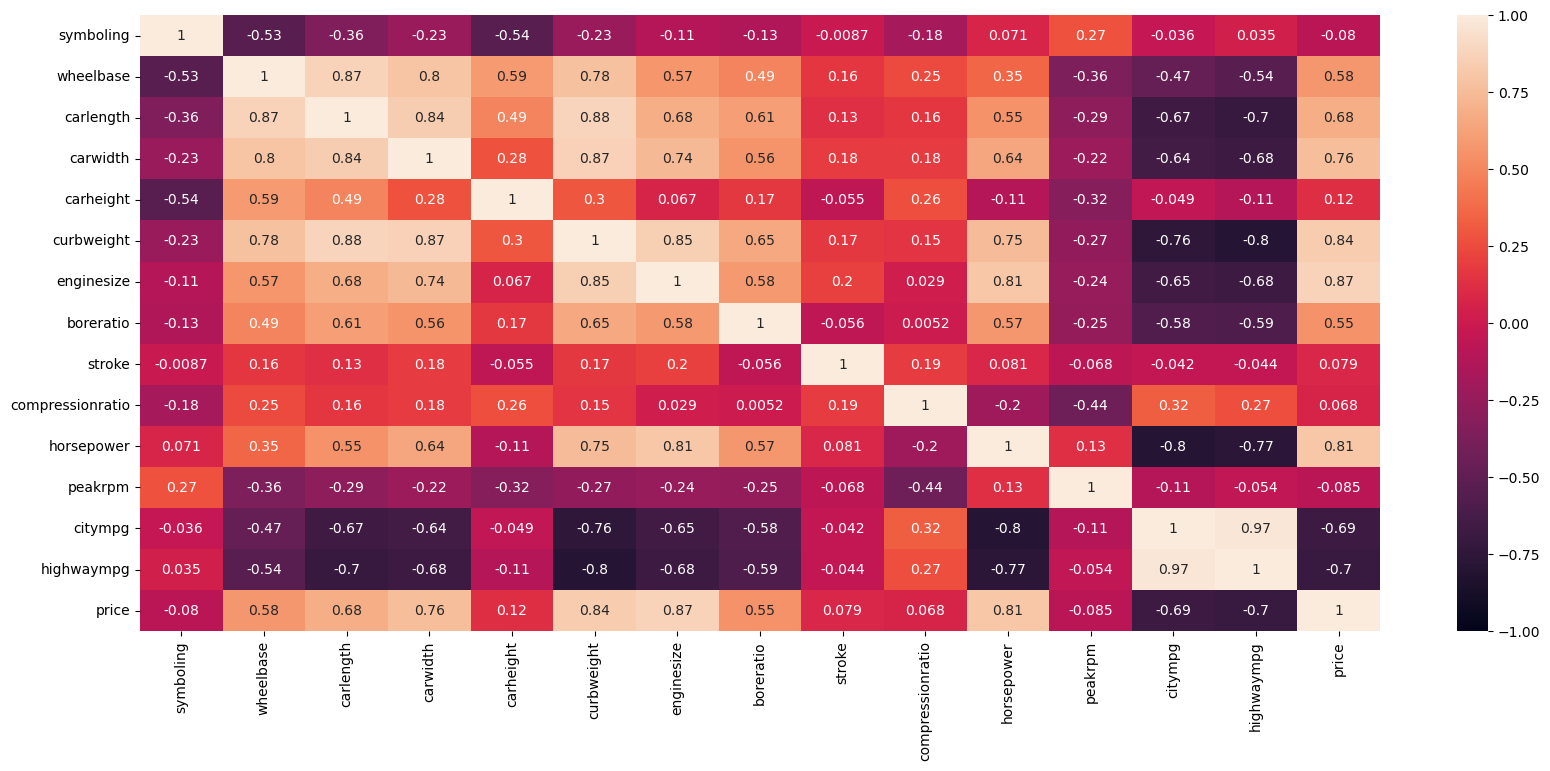

In [15]:
corr_matrix=Out_col1.corr() #feature selection
plt.subplots(figsize=(20,8))
sns.heatmap(corr_matrix,annot=True,vmin=-1,vmax=1)

In [16]:
df.drop(columns="citympg",axis=1,inplace=True)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   symboling         205 non-null    float64
 1   CarName           205 non-null    object 
 2   fueltype          205 non-null    object 
 3   aspiration        205 non-null    object 
 4   doornumber        205 non-null    object 
 5   carbody           205 non-null    object 
 6   drivewheel        205 non-null    object 
 7   enginelocation    205 non-null    object 
 8   wheelbase         205 non-null    float64
 9   carlength         205 non-null    float64
 10  carwidth          205 non-null    float64
 11  carheight         205 non-null    float64
 12  curbweight        205 non-null    float64
 13  enginetype        205 non-null    object 
 14  cylindernumber    205 non-null    object 
 15  enginesize        205 non-null    float64
 16  fuelsystem        205 non-null    object 
 1

In [18]:
df.select_dtypes(include=object)

,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem
0,alfa-romero giulia,gas,std,two,convertible,rwd,front,dohc,four,mpfi
1,alfa-romero stelvio,gas,std,two,convertible,rwd,front,dohc,four,mpfi
2,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi
3,audi 100 ls,gas,std,four,sedan,fwd,front,ohc,four,mpfi
4,audi 100ls,gas,std,four,sedan,4wd,front,ohc,five,mpfi
...,...,...,...,...,...,...,...,...,...,...
200,volvo 145e (sw),gas,std,four,sedan,rwd,front,ohc,four,mpfi
201,volvo 144ea,gas,turbo,four,sedan,rwd,front,ohc,four,mpfi
202,volvo 244dl,gas,std,four,sedan,rwd,front,ohcv,six,mpfi
203,volvo 246,diesel,turbo,four,sedan,rwd,front,ohc,six,idi


In [19]:
df["doornumber"].value_counts()

doornumber
four    115
two      90
Name: count, dtype: int64

In [20]:
df["cylindernumber"].value_counts()

cylindernumber
four      159
six        24
five       11
eight       5
two         4
twelve      1
three       1
Name: count, dtype: int64

In [21]:
mapping={"two":2,"three":3,"four":4,"five":5,"eight":8,"twelve":12,"six":6}
df["doornumber"]=df["doornumber"].map(mapping)
df["cylindernumber"]=df["cylindernumber"].map(mapping)

In [22]:
cate_col=["CarName","fueltype","aspiration","carbody","drivewheel","enginelocation","enginetype","fuelsystem"]

In [23]:
df=pd.get_dummies(df,columns=cate_col,drop_first=True)

In [24]:
df.head()

,symboling,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,...,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,5.0,2,82.65,168.8,64.1,46.75,2548.0,4,130.0,3.470,...,False,False,False,False,False,False,False,True,False,False
1,5.0,2,82.65,168.8,64.1,46.75,2548.0,4,130.0,3.470,...,False,False,False,False,False,False,False,True,False,False
2,1.0,2,94.50,171.2,65.5,52.40,2823.0,6,207.0,2.505,...,False,True,False,False,False,False,False,True,False,False
3,2.0,4,99.80,176.6,66.2,54.30,2337.0,4,109.0,3.190,...,False,False,False,False,False,False,False,True,False,False
4,2.0,4,99.40,176.6,66.4,54.30,2824.0,5,136.0,3.190,...,False,False,False,False,False,False,False,True,False,False


In [25]:
#Splitting the data
y=df["price"]
x=df.drop("price",axis=1)

In [26]:
y

0      13495.0
1      16500.0
2      16500.0
3      13950.0
4      17450.0
        ...   
200    16845.0
201    19045.0
202    21485.0
203    22470.0
204    22625.0
Name: price, Length: 205, dtype: float64

In [27]:
x

,symboling,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,...,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,5.0,2,82.65,168.8,64.1,46.75,2548.0,4,130.0,3.470,...,False,False,False,False,False,False,False,True,False,False
1,5.0,2,82.65,168.8,64.1,46.75,2548.0,4,130.0,3.470,...,False,False,False,False,False,False,False,True,False,False
2,1.0,2,94.50,171.2,65.5,52.40,2823.0,6,207.0,2.505,...,False,True,False,False,False,False,False,True,False,False
3,2.0,4,99.80,176.6,66.2,54.30,2337.0,4,109.0,3.190,...,False,False,False,False,False,False,False,True,False,False
4,2.0,4,99.40,176.6,66.4,54.30,2824.0,5,136.0,3.190,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-3.0,4,114.25,208.3,71.1,55.50,4120.0,4,141.0,4.225,...,False,False,False,False,False,False,False,True,False,False
201,-3.0,4,114.25,208.3,71.1,55.50,4120.0,4,141.0,4.225,...,False,False,False,False,False,False,False,True,False,False
202,-3.0,4,114.25,208.3,71.1,55.50,4120.0,6,207.0,3.580,...,False,True,False,False,False,False,False,True,False,False
203,-3.0,4,114.25,208.3,71.1,55.50,4120.0,6,207.0,2.505,...,False,False,False,False,False,True,False,False,False,False


In [28]:
scaling=StandardScaler()
x=scaling.fit_transform(x)
x=pd.DataFrame(x)
x

,0,1,2,3,4,5,6,7,8,9,...,173,174,175,176,177,178,179,180,181,182
0,1.942507,-1.130388,-1.521370,-0.256126,-0.341169,-1.431804,0.025878,-0.352887,0.132429,0.195507,...,-0.280976,-0.260208,-0.141069,-0.689072,-0.121867,-0.328798,-0.070014,1.086670,-0.214286,-0.070014
1,1.942507,-1.130388,-1.521370,-0.256126,-0.341169,-1.431804,0.025878,-0.352887,0.132429,0.195507,...,-0.280976,-0.260208,-0.141069,-0.689072,-0.121867,-0.328798,-0.070014,1.086670,-0.214286,-0.070014
2,0.061922,-1.130388,-0.377234,-0.152734,0.016317,-0.285004,0.271357,1.502032,1.439744,-1.388284,...,-0.280976,3.843076,-0.141069,-0.689072,-0.121867,-0.328798,-0.070014,1.086670,-0.214286,-0.070014
3,0.532068,0.884652,0.134489,0.079898,0.195061,0.100645,-0.162471,-0.352887,-0.224111,-0.264039,...,-0.280976,-0.260208,-0.141069,-0.689072,-0.121867,-0.328798,-0.070014,1.086670,-0.214286,-0.070014
4,0.532068,0.884652,0.095869,0.079898,0.246130,0.100645,0.272249,0.574572,0.234298,-0.264039,...,-0.280976,-0.260208,-0.141069,-0.689072,-0.121867,-0.328798,-0.070014,1.086670,-0.214286,-0.070014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1.818664,0.884652,1.529660,1.445532,1.446265,0.344213,1.429123,-0.352887,0.319188,1.434639,...,-0.280976,-0.260208,-0.141069,-0.689072,-0.121867,-0.328798,-0.070014,1.086670,-0.214286,-0.070014
201,-1.818664,0.884652,1.529660,1.445532,1.446265,0.344213,1.429123,-0.352887,0.319188,1.434639,...,-0.280976,-0.260208,-0.141069,-0.689072,-0.121867,-0.328798,-0.070014,1.086670,-0.214286,-0.070014
202,-1.818664,0.884652,1.529660,1.445532,1.446265,0.344213,1.429123,1.502032,1.439744,0.376043,...,-0.280976,3.843076,-0.141069,-0.689072,-0.121867,-0.328798,-0.070014,1.086670,-0.214286,-0.070014
203,-1.818664,0.884652,1.529660,1.445532,1.446265,0.344213,1.429123,1.502032,1.439744,-1.388284,...,-0.280976,-0.260208,-0.141069,-0.689072,-0.121867,3.041381,-0.070014,-0.920243,-0.214286,-0.070014


In [29]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)

In [42]:
def build_model(x_train,y_train,x_test,y_test):
    
    
    model={"Linear Regression":LinearRegression(n_jobs=1),
            "Decision Tree": DecisionTreeRegressor(),
            "Random Forest" : RandomForestRegressor(),
            "Gradient Boosting" : GradientBoostingRegressor(),
            "SVR":SVR(),
            "K - Neighbour":KNeighborsRegressor()}
    result=[]
    for name,model in model.items():
        model.fit(x_train,y_train)
        y_pred=model.predict(x_test)

        mae=mean_absolute_error(y_test,y_pred)
        mse=mean_squared_error(y_test,y_pred)
        r2_Score=r2_score(y_test,y_pred)

        result.append({"MODEL":name,
                     "MAE ":mae,
                     "MSE":mse,
                     "R2_score":r2_Score})
        
    result_df=pd.DataFrame(result).sort_values(by="R2_score",ascending=False)

    return result_df



        



In [43]:
model_per=build_model(x_train,y_train,x_test,y_test)
model_per

,MODEL,MAE,MSE,R2_score
2,Random Forest,1722.731123,7.925110e+06,0.878886
3,Gradient Boosting,1895.599560,8.312272e+06,0.872969
1,Decision Tree,2006.622544,8.903159e+06,0.863939
5,K - Neighbour,3818.050985,5.281591e+07,0.192852
4,SVR,5339.585372,6.988468e+07,-0.067998
0,Linear Regression,9338.634099,1.508680e+08,-1.305608


In [49]:
#Hyperparameter Tuning
RF=RandomForestRegressor(random_state=42)
param_grid={"n_estimators": [100,200,300,500],
           "max_depth": [10,20,30,40,None],
           "min_samples_split":[2,5,10]}

randomsearch=RandomizedSearchCV(estimator=RF,param_distributions=param_grid,cv=3,n_jobs=1)
randomsearch.fit(x_train,y_train)
best_model=randomsearch.best_estimator_
y_pred=best_model.predict(x_test)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(mae)
print(mse)
print(r2)

1694.6685490196078
7541732.952482171
0.8847450567025705
